# 04 · Analysis 2 — profitability pressure is broad across industries

Analysis 1 reported an improving national picture. This notebook asks what that national average is
hiding, by industry.

**Measure:**

> **Net profitability balance = % expecting profitability to increase − % expecting it to decrease**

**Why this measure:** it uses both directional responses while leaving *stay about the same*
genuinely neutral — it is not split between the two sides. Critically, it needs **no assumption that
the three shares total 100**, which notebook `01` showed would be false. A single number per industry
also makes 13 industries comparable at a glance.

## Setup

In [1]:
import sys
from pathlib import Path

# Walk up until src/csbc.py is found, so the notebook runs whether Jupyter was started
# in the project root or in src/. Nothing here depends on an absolute path.
_here = Path.cwd().resolve()
_root = next(p for p in (_here, *_here.parents) if (p / "src" / "csbc.py").exists())
sys.path.insert(0, str(_root / "src"))

import pandas as pd
import matplotlib.pyplot as plt

import csbc

csbc.ensure_dirs()
csbc.apply_chart_theme()

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 48)

print(f"project: {csbc.ROOT.name}/")
print(f"raw data: {len(sorted(csbc.RAW_DIR.glob('*.csv')))} quarterly CSVs in data/raw")

project: business_data_lab_assignment/
raw data: 4 quarterly CSVs in data/raw


In [2]:
csbc_data = csbc.load_combined()
QUARTERS = csbc.sort_quarters(csbc_data["Quarter"])

print(f"{len(csbc_data):,} rows | quarters: {', '.join(QUARTERS)}")

9,408 rows | quarters: Q3 2023, Q4 2023, Q1 2024, Q2 2024


## Q2 2024 by industry

Canada-level observations, excluding the all-industries aggregate so the 13 industries are compared
against each other rather than against their own total.

In [3]:
QUARTER = "Q2 2024"

# sector_balance_table refuses to compute where increase or decrease is missing, rather
# than treating a blank as zero - that would read as "nobody expects a decrease".
sectors = csbc.sector_balance_table(csbc_data, QUARTER)

negative = int((sectors["net_balance_pp"] < 0).sum())
print(f"{negative} of {len(sectors)} industries have a negative profitability balance in {QUARTER}")
sectors

12 of 13 industries have a negative profitability balance in Q2 2024


Expected_change,increase,stay about the same,decrease,net_balance_pp
Business_characteristics,,,,
"Agriculture, forestry, fishing and hunting",6.5,45.8,47.4,-40.9
Accommodation and food services,14.2,41.4,44.2,-30.0
Transportation and warehousing,13.1,45.8,41.0,-27.9
Health care and social assistance,5.8,59.9,27.8,-22.0
Retail trade,14.6,52.4,33.0,-18.4
Real estate and rental and leasing,11.0,60.5,27.3,-16.3
Wholesale trade,15.3,53.2,31.4,-16.1
"Mining, quarrying, and oil and gas extraction",12.1,61.4,26.5,-14.4
Manufacturing,19.5,49.9,30.6,-11.1


## Chart

**Form: diverging horizontal bar.** The quantity is signed, so the zero line has to be visible and
the two directions need opposite colours. Horizontal because the industry names are long, and sorted
worst-first so the chart reads in the order a reader scans.

A pie chart would be wrong here: 13 categories, many of them close together, and the values are not
parts of a whole.

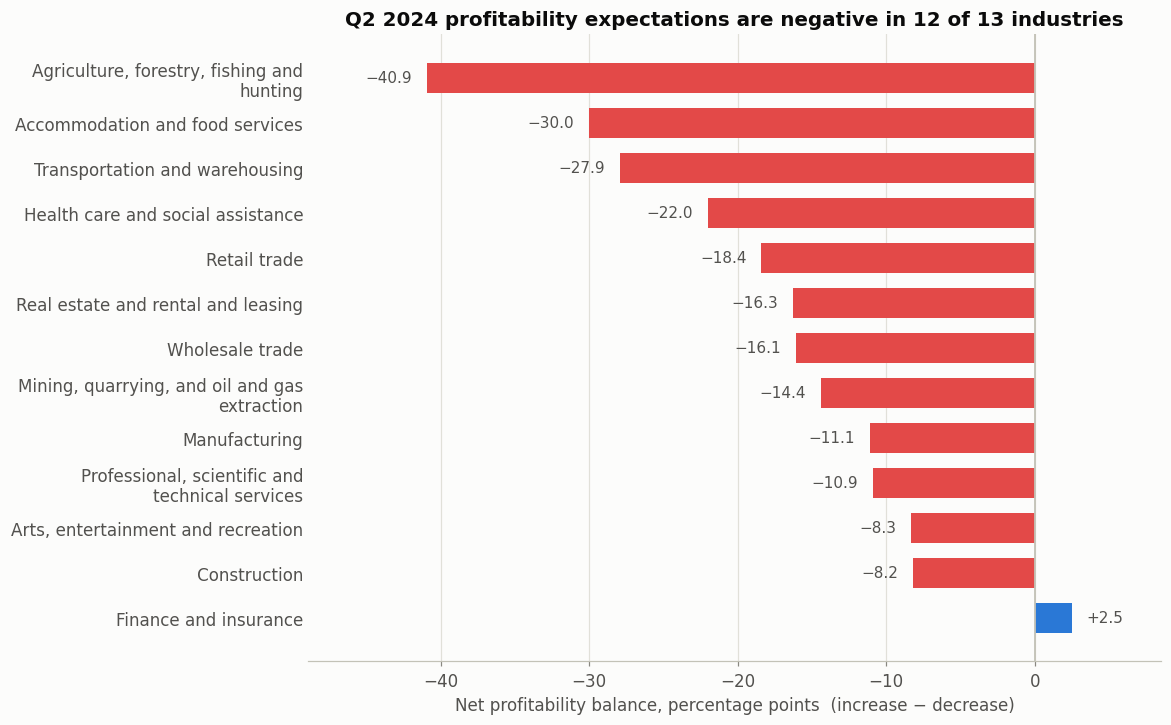

wrote outputs/analysis_2_metrics.csv


In [4]:
csbc.sector_balance_chart(
    csbc_data, QUARTER,
    csbc.OUTPUT_DIR / "analysis_2_sector_profitability_balance.png",
)
sectors.sort_values("net_balance_pp", ascending=False).to_csv(
    csbc.OUTPUT_DIR / "analysis_2_metrics.csv"
)
print("wrote outputs/analysis_2_metrics.csv")

## Is this new, or has it always been like this?

A single quarter cannot answer that, and it is the first question a stakeholder should ask. "Margins
are under pressure" means nothing without a baseline, so here is the same measure for all four
quarters.

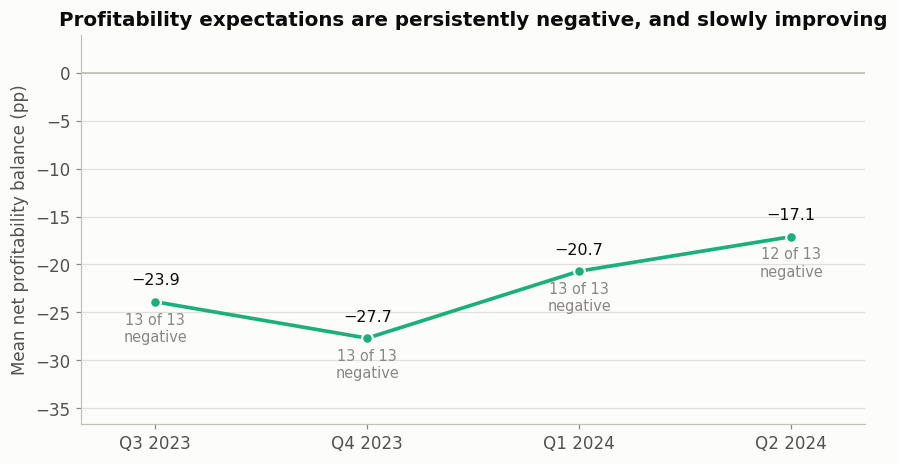

,industries,negative,mean_balance_pp,median_balance_pp,worst_balance_pp
Quarter,,,,,
Q3 2023,13,13,-23.9,-21.5,-50.2
Q4 2023,13,13,-27.7,-26.4,-43.2
Q1 2024,13,13,-20.7,-22.4,-44.2
Q2 2024,13,12,-17.1,-16.1,-40.9


In [5]:
trend = csbc.sector_balance_trend_chart(
    csbc_data, csbc.OUTPUT_DIR / "analysis_2_balance_trend.png",
)
trend.to_csv(csbc.OUTPUT_DIR / "analysis_2_balance_trend.csv")
trend

This materially changes the reading. Margin pessimism is **not new** — every one of the 13 industries
carried a negative balance in each of the first three quarters. Q2 2024 is the **least bad quarter of
the four**: the mean balance improved from −23.9 pp to −17.1 pp and, for the first time, one industry
turned positive.

So the honest framing is **entrenched, slowly easing pessimism** — not an emerging squeeze. Note also
that profitability expectations improved *alongside* sales rather than against them, which is what
notebook `02`'s r = 0.58 would predict. The striking fact is the **level**, not a divergence in
direction.

## Sales and margins, industry by industry

In [6]:
# Do industries expecting decent sales growth still expect margins to fall?
sales = csbc_data[
    (csbc_data["GEO"] == "Canada")
    & (csbc_data["Business_characteristics"] != csbc.ALL_INDUSTRIES)
    & (csbc_data["Business_information"] == "Sales")
    & (csbc_data["Expected_change"] == "increase")
    & (csbc_data["Quarter"] == QUARTER)
].set_index("Business_characteristics")["VALUE"]

comparison = pd.DataFrame({
    "sales increase %": sales,
    "profitability balance pp": sectors["net_balance_pp"],
}).sort_values("profitability balance pp")

both_ways = comparison[(comparison["sales increase %"] >= 15)
                       & (comparison["profitability balance pp"] < 0)]
print(f"industries expecting sales growth of 15%+ yet falling margins: "
      f"{len(both_ways)} of {len(comparison)}")
comparison.round(1)

industries expecting sales growth of 15%+ yet falling margins: 8 of 13


,sales increase %,profitability balance pp
Business_characteristics,,
"Agriculture, forestry, fishing and hunting",12.0,-40.9
Accommodation and food services,30.6,-30.0
Transportation and warehousing,20.1,-27.9
Health care and social assistance,8.6,-22.0
Retail trade,24.6,-18.4
Real estate and rental and leasing,20.3,-16.3
Wholesale trade,23.5,-16.1
"Mining, quarrying, and oil and gas extraction",12.7,-14.4
Manufacturing,24.5,-11.1


## Interpretation

In Q2 2024, **12 of 13 industries** carry a negative profitability balance. Expected margin pressure
is **broad rather than sector-specific**.

- **Agriculture, forestry, fishing and hunting** is weakest at **−40.9 pp** (6.5% expect an increase
  against 47.4% expecting a decrease), followed by **accommodation and food services** (−30.0 pp) and
  **transportation and warehousing** (−27.9 pp).
- **Finance and insurance** is the only industry in positive territory, at **+2.5 pp**.

**The level is the finding, and its persistence is what makes it matter.** For four consecutive
quarters, essentially every industry has expected profitability to fall. Even at the best reading in
the window, 12 of 13 still do — while sales expectations sit at a four-quarter high. Several
industries expect solid sales growth *and* falling margins at the same time.

That combination points away from a demand problem and toward a **cost problem**: firms anticipating
they can sell more without keeping more of it. Input costs, wages, financing costs and limited pricing
power are the obvious candidates, but none are in this dataset, so they remain hypotheses to test.

**What I would tell a stakeholder.** Do not read the improving national sales figure as improving
business health — margin expectations have been negative almost everywhere for a year, and are only
slowly recovering. Two things follow. First, the direction is genuinely encouraging: this is the best
of the four quarters. Second, the level is not: a business expecting more sales and thinner margins
behaves cautiously, which is the most plausible reading of why investment has not moved. I would use
this balance as a **screening tool** — agriculture, accommodation and food services, and
transportation and warehousing are where deeper sector work would pay off first.

---

**Next:** `05_analysis_regional_dispersion.ipynb` — whether the national improvement was shared
across the country.

---

*All logic lives in [`csbc.py`](csbc.py) so the notebooks, the tests and the pipeline CLI
share one implementation.*